In [1]:
"""
PROGRAM hdim_14.py codes THE HIGH DIMENSIONAL CLUSTERING ALGORITHM
for example, for clustering embedding vectors created from text samples

VARAIBLES
np.array adata floating point input data
np.array bdata integer 0,1
np.array cdata cols reordered so most useful cols, lowest variance, to the left
"""
import numpy as np
from scipy import stats
import math as math
import matplotlib.pyplot as plt
import time
from datetime import datetime
import matplotlib.pyplot as plt
import random

In [2]:
def filein(fname):
    numlines = 0
    xin = []
    f = open(fname, 'r')
    for line in f:
        # print (line, end='')
        xin.append(line)
        numlines = numlines+1
    f.close()
    return xin, numlines
    data, numlines = filein(fname)
    # print ('\ndata\n',data,'\nlines',numlines)
    x = ['0' for i in range(numlines)]
    for i in range(numlines):
        x[i] = data[i].replace('\n', '')
        x[i] = eval(x[i])
    return x, numlines


In [3]:
# reads any text table with n columns
# elements in a row separated by a TAB
# rows separated by a RETURN

def getxn(fname):
    data, numlines = filein(fname)
    dataline = ['0' for i in range(numlines)]
    for i in range(numlines):
        x = data[i]
        y = x.split('\t')
        y[-1] = y[-1].replace('\n', '')
        dataline[i] = y
    # print ('\n\nascii-input',dataline)
    xdata = dataline[:]
    for i in range(numlines):
        inline = len(dataline[i])
        for j in range(inline):
            if xdata[i][j] != '':
                xdata[i][j] = eval(xdata[i][j])
            else:
                xdata[i][j] = None
    # print ('dataline',dataline)
    # print ('xdata',xdata)
    return xdata, numlines

In [4]:

def binary_summary_report(arr):
    """
    Takes a 2D binary array, sorts it, and prints a summary table.
    """
    nrows, ncols = arr.shape

    # 1. Convert to Decimal using Dot Product (Fastest)
    # Using 'object' dtype handles up to 100+ columns if necessary,
    # but for < 64 bits, standard int64 is used automatically.
    powers = 1 << np.arange(ncols)[::-1]
    decimal_values = arr.dot(powers)

    # 2. Get unique values and their frequencies
    unique_vals, counts = np.unique(decimal_values, return_counts=True)

    # 3. Reconstruct Binary Rows for display (Vectorized)
    # This creates a bitmask to turn decimals back into [1, 0, 1, 0] format
    unique_binary_rows = ((unique_vals[:, None] & (
        1 << np.arange(ncols)[::-1])) > 0).astype(int)

    # 4. Print the Summary Table
    header = f"{'Unique Decimal':<15} | {
        'Binary Equivalent':<25} | {'Count (Frequency)':<15}"
    print(header)
    print("-" * len(header))

    for i in range(len(unique_vals)):
        # Convert to list for cleaner printing
        bin_row = unique_binary_rows[i].tolist()
        print(f"{unique_vals[i]:<15} | {str(bin_row):<25} | {counts[i]:<15}")

    # Return the dictionary as requested previously
    return dict(zip(unique_vals, counts))

In [5]:
def draw_flexible_box_grid(n, label_list, datain, now):
    total_boxes = 2**n

    # 1. Determine Grid Dimensions (Width >= Height)
    width = 2**((n + 1) // 2)
    height = 2**(n // 2)

    # 2. Handle Custom Labels
    # Convert to list and pad with empty strings if the user provided too few
    full_labels = list(label_list)
    if len(full_labels) < total_boxes:
        full_labels += [""] * (total_boxes - len(full_labels))

    # Take only the amount needed for the grid
    display_labels = full_labels[:total_boxes]

    # 3. Reshape into the grid matrix
    grid_labels = np.array(display_labels).reshape(height, width)

    fig, ax = plt.subplots(figsize=(width * 1.5, height * 1.5))

    for i in range(height):
        for j in range(width):
            # Coordinates for top-down numbering
            rect = plt.Rectangle((j, height - i - 1), 1, 1,
                                 fill=False, edgecolor='black', linewidth=2)
            ax.add_patch(rect)

            # Place the custom label
            ax.text(j + 0.5, height - i - 0.5, grid_labels[i, j],
                    ha='center', va='center',
                    fontsize=12 if n < 5 else 9)

    ax.set_xlim(0, width)
    ax.set_ylim(0, height)
    ax.set_aspect('equal')
    ax.axis('off')
    # plt.title(f"Custom Grid: n={n} ({width}x{height})", pad=20)
    # newtitle = datain+'    '+f"total_boxes={total_boxes}"+ '    ' +now
    newtitle = programname+'    '+datain+'    '+f"boxes={total_boxes}"+\
        '    ' +titlenote+'    '+now
    plt.title(newtitle, pad=20)
    plt.show()

In [6]:
programname='hidim_14.py'
# inout data
# cols separated by TAB
# reos sepsarated by RETURN
# floatihng point numers [0,1]
"""data input: rows separated by TAB, col separated by RETURN, no headers, no row names
rows = each vector, cols = elements of each vector
input numbers: floating point, typically [-1,1]
(I know, everyone else uses Pandas, when I learned python it was fun to create my own file opening/closing (def filein) and
parsing (def getxn) functions, I've stuck with that, sorry.)
"""
inputname = input('\ninput file namem (e.g. data6.txt)')
titlenote=input('\ninput title note (e.g. noise=0.7)')
data, ndata = getxn(inputname)
print('\ndata= ', data)
adata = np.array(data)
print('\nadata.shape (row,col)', adata.shape)
[nrow, ncol] = adata.shape


input file namem (e.g. data6.txt) data6.txt

input title note (e.g. noise=0.7) 



data=  [[0, -0.48, 0.27, -0.86, 0.86], [1, 0.48, 0.22, 0.05, 0.34], [2, 0.09, -0.25, 0.65, 0.48], [3, -0.1, -0.35, -0.91, 0.39], [4, 0.96, 0.13, 0.42, 0.7], [5, 0.82, 0.44, -0.78, -0.31], [6, -0.06, -0.28, -0.27, 0.92]]

adata.shape (row,col) (7, 5)


In [7]:
"""floating point to integer, convert [<=0, >0] to  [0,1]"""

bdata = np.zeros((nrow, ncol), dtype=int)
# #make bdata[i,j] = 0 (if adata <= 0) = 1 (if adata > 0)
for irow in range(nrow):
    for icol in range(ncol):
        if adata[irow, icol] > 0.:
            bdata[irow, icol] = 1
print('\nbdata\n', bdata)


bdata
 [[0 0 1 0 1]
 [1 1 1 1 1]
 [1 1 0 1 1]
 [1 0 0 0 1]
 [1 1 1 1 1]
 [1 1 1 0 0]
 [1 0 0 0 1]]


In [8]:
# DO HAMMING DISTANCE COLS
"""find the variance = min Hamming distance to all 0's or all 1's in each COL"""

target_0 = np.zeros((nrow), dtype=int)
target_1 = np.ones((nrow), dtype=int)
# for icol in range (ncol)
ham = np.zeros((ncol), dtype=int)
for icol in range(ncol):
    col_test = bdata[:, icol].copy()
    # print ('\ni, col_test= ',icol,col_test)
    ham_0 = np.sum(col_test != target_0)
    ham_1 = np.sum(col_test != target_1)
    ham[icol] = min(ham_0, ham_1)
    print('\ntarget_0, target_1, ham     ', ham_0, ham_1, ham[icol])


target_0, target_1, ham      6 1 1

target_0, target_1, ham      4 3 3

target_0, target_1, ham      4 3 3

target_0, target_1, ham      3 4 3

target_0, target_1, ham      6 1 1


In [9]:
# first sort ham
# want the position in ham to be the min value
"""cdata = sort the cols from low to high variance"""

hamlow = np.zeros((ncol), dtype=int)
hamlow = np.argsort(ham)
cdata = bdata[:, hamlow]  # pretty fancy, thank you Gemini
print('\nbdata\n', bdata)
print('\ncdata\n', cdata)


bdata
 [[0 0 1 0 1]
 [1 1 1 1 1]
 [1 1 0 1 1]
 [1 0 0 0 1]
 [1 1 1 1 1]
 [1 1 1 0 0]
 [1 0 0 0 1]]

cdata
 [[0 1 0 1 0]
 [1 1 1 1 1]
 [1 1 1 0 1]
 [1 1 0 0 0]
 [1 1 1 1 1]
 [1 0 1 1 0]
 [1 1 0 0 0]]


Sorted Array:
 []

Unique Decimal Values: [0]
Frequency Counts:      [7]
Unique Decimal  | Binary Equivalent         | Count (Frequency)
---------------------------------------------------------------
0               | []                        | 7              


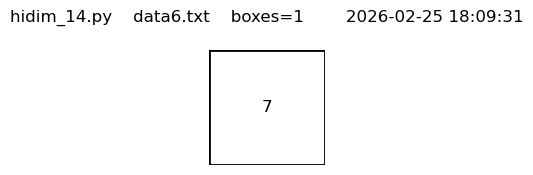

Sorted Array:
 [[0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]]

Unique Decimal Values: [0 1]
Frequency Counts:      [1 6]
Unique Decimal  | Binary Equivalent         | Count (Frequency)
---------------------------------------------------------------
0               | [0]                       | 1              
1               | [1]                       | 6              


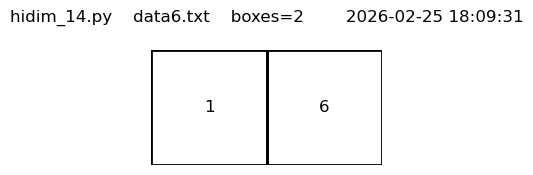

Sorted Array:
 [[0 1]
 [1 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]]

Unique Decimal Values: [1 2 3]
Frequency Counts:      [1 1 5]
Unique Decimal  | Binary Equivalent         | Count (Frequency)
---------------------------------------------------------------
1               | [0, 1]                    | 1              
2               | [1, 0]                    | 1              
3               | [1, 1]                    | 5              


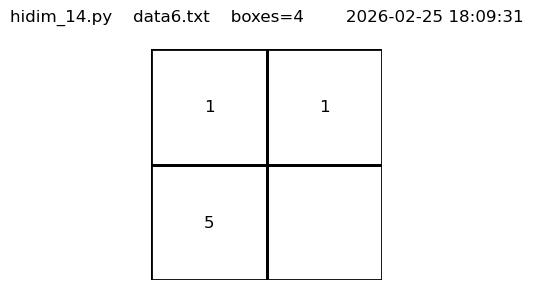

Sorted Array:
 [[0 1 0]
 [1 0 1]
 [1 1 0]
 [1 1 0]
 [1 1 1]
 [1 1 1]
 [1 1 1]]

Unique Decimal Values: [2 5 6 7]
Frequency Counts:      [1 1 2 3]
Unique Decimal  | Binary Equivalent         | Count (Frequency)
---------------------------------------------------------------
2               | [0, 1, 0]                 | 1              
5               | [1, 0, 1]                 | 1              
6               | [1, 1, 0]                 | 2              
7               | [1, 1, 1]                 | 3              


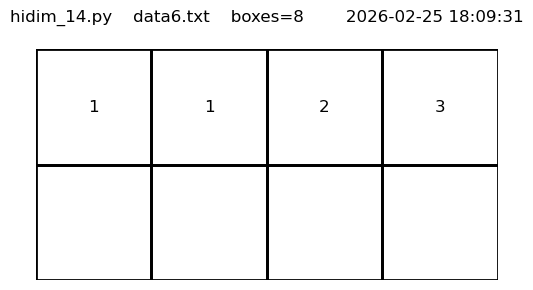

Sorted Array:
 [[0 1 0 1]
 [1 0 1 1]
 [1 1 0 0]
 [1 1 0 0]
 [1 1 1 0]
 [1 1 1 1]
 [1 1 1 1]]

Unique Decimal Values: [ 5 11 12 14 15]
Frequency Counts:      [1 1 2 1 2]
Unique Decimal  | Binary Equivalent         | Count (Frequency)
---------------------------------------------------------------
5               | [0, 1, 0, 1]              | 1              
11              | [1, 0, 1, 1]              | 1              
12              | [1, 1, 0, 0]              | 2              
14              | [1, 1, 1, 0]              | 1              
15              | [1, 1, 1, 1]              | 2              


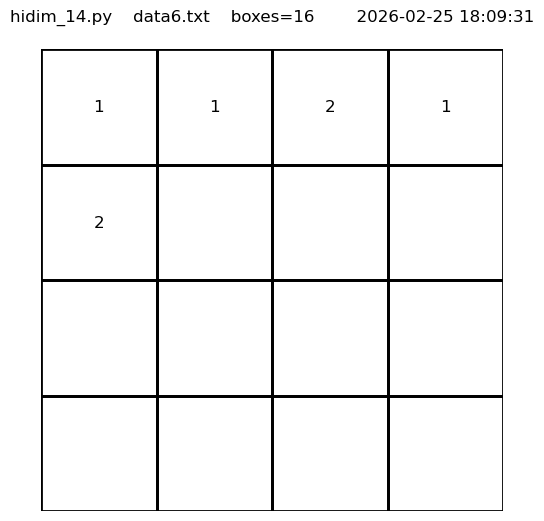

Sorted Array:
 [[0 1 0 1 0]
 [1 0 1 1 0]
 [1 1 0 0 0]
 [1 1 0 0 0]
 [1 1 1 0 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]

Unique Decimal Values: [10 22 24 29 31]
Frequency Counts:      [1 1 2 1 2]
Unique Decimal  | Binary Equivalent         | Count (Frequency)
---------------------------------------------------------------
10              | [0, 1, 0, 1, 0]           | 1              
22              | [1, 0, 1, 1, 0]           | 1              
24              | [1, 1, 0, 0, 0]           | 2              
29              | [1, 1, 1, 0, 1]           | 1              
31              | [1, 1, 1, 1, 1]           | 2              


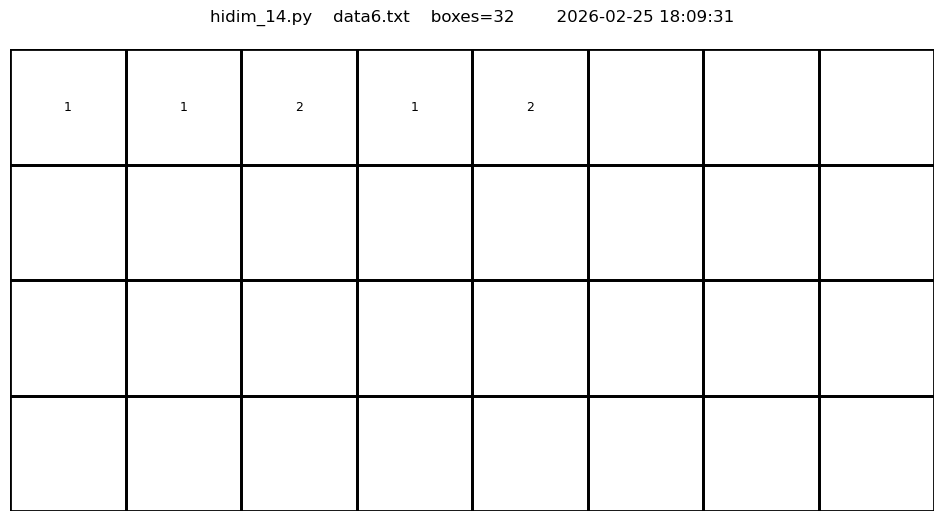

In [10]:
# OK that's ALL sorted, let's now do the BIGLOOP
# OK MESSED UP dont need to run SORT but do need COURNTS
"""look only at the first k bits of each row
	if two rows have the same first k bits, put them in the same box (cluster)
	find unique rows, how often each, use: np.unique(rows, return_counts=True)
	Increase k (1, 2, 3, . . .) max = 63, (range(6) < 63  in line 220)
	(beyond 63 requires np.lexsort which is much slower than np.argsort)
	small k → fewer, bigger clusters
	bigger k → more, smaller clusters
then for each k
	output table of results, output box plot with number of rows in each box"""
now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
for bigloop in range(6):  # not doing anything yet
    n = 2**bigloop
    edata = cdata[:, 0:bigloop]
    mrow, mcol = edata.shape
    mpowers = 1 << np.arange(mcol)[::-1]
    mdecimal_values = edata.dot(mpowers)
    sorted_indices = np.argsort(mdecimal_values)
    sorted_e = edata[sorted_indices]
    munique_decimals, mcounts = np.unique(mdecimal_values, return_counts=True)
    # 5. Result Display
    print("Sorted Array:\n", sorted_e)
    print("\nUnique Decimal Values:", munique_decimals)
    print("Frequency Counts:     ", mcounts)
    results = binary_summary_report(edata)
# my_labels = ["Start", "A1", "B2", "C3", "D4", "E5", "F6", "End"]
    my_labels = mcounts.astype(str).tolist()
    draw_flexible_box_grid(bigloop, my_labels, inputname, now)